# Multi-Layer Perceptron (MLP) - Supervised Binary Classification Task

The  pipeline implements a Multi-Layer Perceptron (MLP), a type of feedforward artificial neural network for the first supervised task. MLPs  consisting of an input layer, one or more hidden layers of computational nodes, and an output layer, where each node applies a non-linear activation function (such as ReLU or Sigmoid) to the weighted sum of its inputs. The network is trained via backpropagation, with an algorithm that calculates the gradient of a loss function with respect to the network's weights. It minimizes error through stochastic gradient descent or its variants.

As before, we include a flexible preprocessing architecture and an extensive set of hyperparameters for fine-tuning the network's architecture and learning process. The options in terms of data preprocessing and hyperparameters are the same as in the Logistic Regression models. As before, the balancing and standardization of data can be tested through the variables at the beginning of the 

Since the MLP function we used does not have an automatic data balancing function, this was accomplished by randomly downsampling the number of non-donors (majority class) to the same number as the donors (minority class). We again implemented the BALANCED option in the code, to allow for a comparison. 

**Several hyperparameters can be tested using this pipeline:**

hidden_layer_sizes: The number of layers and neurons per layers. 

activation: The activation function for the hidden layers (e.g., 'relu'). 

solver: The optimization algorithm.

alpha: regularization parameter that helps prevent overfitting by penalizing large weights.

early_stopping: A mechanism to halt training if the validation score stops improving, preventing the model from memorizing noise in the training data.

max_iter: The limit on the number of epochs (passes through the data) the solver can perform.

TARGET_B                      0
MONTHS_SINCE_ORIGIN           0
IN_HOUSE                      0
MOR_HIT_RATE                  0
MEDIAN_HOME_VALUE             0
MEDIAN_HOUSEHOLD_INCOME       0
PCT_OWNER_OCCUPIED            0
PER_CAPITA_INCOME             0
PCT_ATTRIBUTE1                0
PCT_ATTRIBUTE2                0
PCT_ATTRIBUTE3                0
PCT_ATTRIBUTE4                0
PEP_STAR                      0
RECENT_STAR_STATUS            0
FREQUENCY_STATUS_97NK         0
RECENT_RESPONSE_PROP          0
RECENT_AVG_GIFT_AMT           0
RECENT_CARD_RESPONSE_PROP     0
RECENT_AVG_CARD_GIFT_AMT      0
RECENT_RESPONSE_COUNT         0
RECENT_CARD_RESPONSE_COUNT    0
LIFETIME_CARD_PROM            0
LIFETIME_PROM                 0
LIFETIME_GIFT_AMOUNT          0
LIFETIME_GIFT_COUNT           0
LIFETIME_AVG_GIFT_AMT         0
LIFETIME_GIFT_RANGE           0
LIFETIME_MAX_GIFT_AMT         0
LIFETIME_MIN_GIFT_AMT         0
LAST_GIFT_AMT                 0
CARD_PROM_12                  0
NUMBER_P

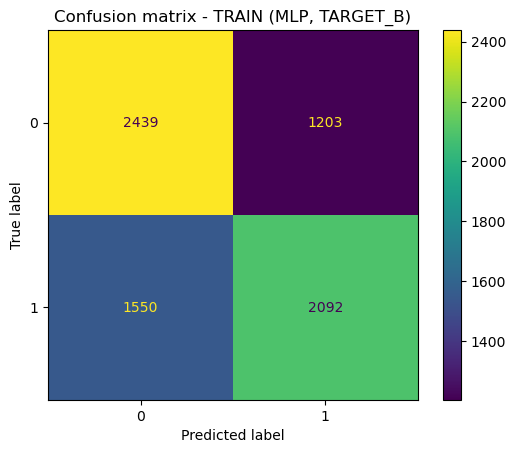

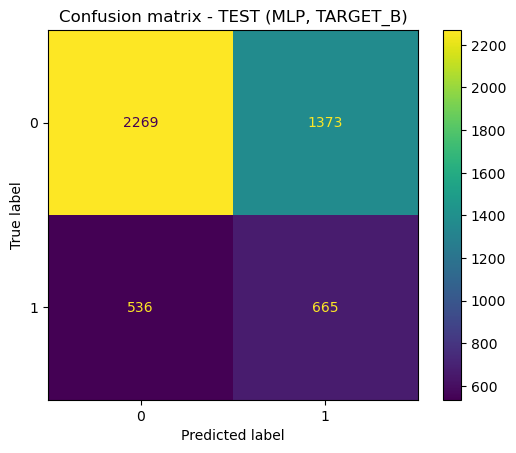

TRAIN classification report:
              precision    recall  f1-score   support

           0       0.61      0.67      0.64      3642
           1       0.63      0.57      0.60      3642

    accuracy                           0.62      7284
   macro avg       0.62      0.62      0.62      7284
weighted avg       0.62      0.62      0.62      7284

TEST classification report:
              precision    recall  f1-score   support

           0       0.81      0.62      0.70      3642
           1       0.33      0.55      0.41      1201

    accuracy                           0.61      4843
   macro avg       0.57      0.59      0.56      4843
weighted avg       0.69      0.61      0.63      4843



In [43]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.utils import resample

#for more information: https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
hidden_layer_sizes = (200,200,100,100,200) 
activation = 'relu' # 'relu'
solver = 'adam'  #'adam'
alpha = 0.0001    # 0.0001
early_stopping=True
max_iter = 500

STANDARDIZE = True
BALANCE = True

df_donors = pd.read_csv('Donors_dataset.csv')

num_features = num_features = [
    "MONTHS_SINCE_ORIGIN",
    "IN_HOUSE",
    "MOR_HIT_RATE",
    "MEDIAN_HOME_VALUE",
    "MEDIAN_HOUSEHOLD_INCOME",
    "PCT_OWNER_OCCUPIED",
    "PER_CAPITA_INCOME",
    "PCT_ATTRIBUTE1",
    "PCT_ATTRIBUTE2",
    "PCT_ATTRIBUTE3",
    "PCT_ATTRIBUTE4",
    "PEP_STAR",
    "RECENT_STAR_STATUS",
    "FREQUENCY_STATUS_97NK",
    "RECENT_RESPONSE_PROP",
    "RECENT_AVG_GIFT_AMT",
    "RECENT_CARD_RESPONSE_PROP",
    "RECENT_AVG_CARD_GIFT_AMT",
    "RECENT_RESPONSE_COUNT",
    "RECENT_CARD_RESPONSE_COUNT",
    "LIFETIME_CARD_PROM",
    "LIFETIME_PROM",
    "LIFETIME_GIFT_AMOUNT",
    "LIFETIME_GIFT_COUNT",
    "LIFETIME_AVG_GIFT_AMT",
    "LIFETIME_GIFT_RANGE",
    "LIFETIME_MAX_GIFT_AMT",
    "LIFETIME_MIN_GIFT_AMT",
    "LAST_GIFT_AMT",
    "CARD_PROM_12",
    "NUMBER_PROM_12",
    "MONTHS_SINCE_LAST_GIFT",
    "MONTHS_SINCE_FIRST_GIFT",
    "FILE_AVG_GIFT",
    "FILE_CARD_GIFT"
]


cat_features = [
]     

# Keeping only TARGET_B + selected predictors
df_B = df_donors[['TARGET_B'] + num_features + cat_features].copy() #copies the chosen features to df_B

# check missing values in these columns
print(df_B.isna().sum()) # df_B.isna() creates a dataframe with True and False, in terms of having a value. Then all the trues are summed as ones.

for col in num_features:
    df_B[col + "_unknown"] = df_B[col].isna().astype(int)
    median_val = df_B[col].median()
    df_B[col] = df_B[col].fillna(median_val)

for col in cat_features:
    df_B[col] = df_B[col].fillna("Unknown")

# One-hot encode categorical variables. Creates Dummy tables for the categorical features.
df_B_encoded = pd.get_dummies(df_B, columns=cat_features, drop_first=True) #  The drop_first, condenses the results by making one of the features the reference. supposidly it does not affect the results.

# Final X and y for TARGET_B model
X_B = df_B_encoded.drop('TARGET_B', axis=1)
y_B = df_B_encoded['TARGET_B']

X_B.head()



# Train/test split
X_B_train, X_B_test, y_B_train, y_B_test = train_test_split(
    X_B, y_B, random_state=42
)

if BALANCE:
    train_df = pd.concat([X_B_train, y_B_train], axis=1)

    train_non_donors = train_df[train_df['TARGET_B'] == 0]
    train_donors = train_df[train_df['TARGET_B'] == 1]

    # Undersampling non-donors.
    train_non_donors_undersample = resample( # resample is a function from scikit-learn, used for this exact purpose. I will randomly select a number of non donors, to match the donors.
        train_non_donors,
        replace=False,
        n_samples=len(train_donors),
        random_state=42
    )

    # Concatenate to get balanced train set
    train_balanced = pd.concat([train_non_donors_undersample, train_donors])

    X_B_train_bal = train_balanced.drop('TARGET_B', axis=1)
    y_B_train_bal = train_balanced['TARGET_B']
else:
    X_B_train_bal = X_B_train
    y_B_train_bal = y_B_train

# Standardize features (as in TP12)
if STANDARDIZE:
    sc = StandardScaler()
    sc.fit(X_B_train_bal)
    X_B_train_std = sc.transform(X_B_train_bal)
    X_B_test_std  = sc.transform(X_B_test)
else:
    X_B_train_std = X_B_train_bal
    X_B_test_std  = X_B_test

# Neural network (MLPClassifier), similar style to TP12
mlp_B = MLPClassifier(max_iter=max_iter, random_state=10, 
                      alpha=alpha, 
                      early_stopping=early_stopping, 
                      hidden_layer_sizes=hidden_layer_sizes,
                      solver=solver
                      )


mlp_B.fit(X_B_train_std, y_B_train_bal)

print("Train set accuracy =", mlp_B.score(X_B_train_std, y_B_train_bal))
print("Test set accuracy  =", mlp_B.score(X_B_test_std, y_B_test))


###### Confusion matrices
y_B_train_pred = mlp_B.predict(X_B_train_std)
y_B_test_pred  = mlp_B.predict(X_B_test_std)

cm_train = confusion_matrix(y_B_train_bal, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train,
                                    display_labels=mlp_B.classes_)
disp_train.plot()
plt.title("Confusion matrix - TRAIN (MLP, TARGET_B)")
plt.show()

cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test,
                                   display_labels=mlp_B.classes_)
disp_test.plot()
plt.title("Confusion matrix - TEST (MLP, TARGET_B)")
plt.show()

# Classification report
print("TRAIN classification report:")
print(classification_report(y_B_train_bal, y_B_train_pred))

print("TEST classification report:")
print(classification_report(y_B_test, y_B_test_pred))


--- Results with Threshold: 0 ---
Train Accuracy: 0.2507
Test Accuracy:  0.2480


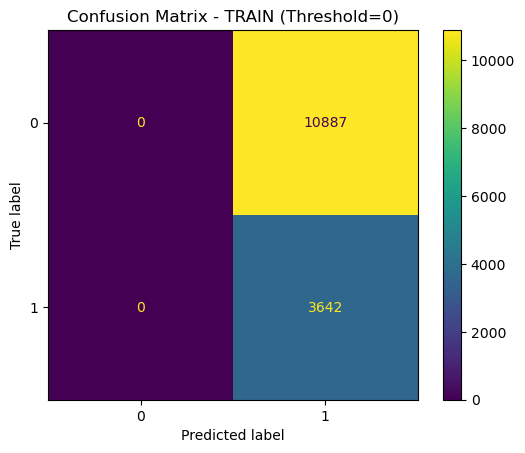

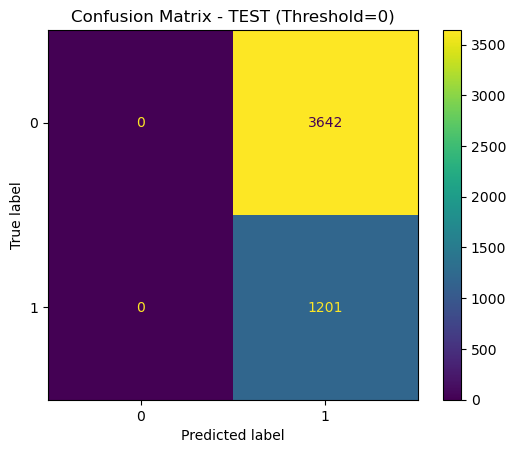


TRAIN Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00     10887
           1       0.25      1.00      0.40      3642

    accuracy                           0.25     14529
   macro avg       0.13      0.50      0.20     14529
weighted avg       0.06      0.25      0.10     14529

TEST Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3642
           1       0.25      1.00      0.40      1201

    accuracy                           0.25      4843
   macro avg       0.12      0.50      0.20      4843
weighted avg       0.06      0.25      0.10      4843

TEST AUC (TARGET_B): 0.5473


c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\Admin\anaconda3\Lib\site-packag

In [13]:
# --- 1. CUSTOM THRESHOLD LOGIC ---
THRESHOLD = 0  # Set your desired threshold here (e.g., 0.3 to catch more donors)

# Get raw probabilities for Class 1 (Donors)
# predict_proba returns [prob_class_0, prob_class_1]
y_probs_train = mlp_B.predict_proba(X_B_train_std)[:, 1]
y_probs_test  = mlp_B.predict_proba(X_B_test_std)[:, 1]

# Apply manual threshold to create predictions
y_B_train_pred = (y_probs_train >= THRESHOLD).astype(int)
y_B_test_pred  = (y_probs_test >= THRESHOLD).astype(int)

# --- 2. PRINTING THE REPORT ---

# Calculate Accuracy manually (since .score() uses default 0.5)
from sklearn.metrics import accuracy_score
train_acc = accuracy_score(y_B_train_bal, y_B_train_pred)
test_acc  = accuracy_score(y_B_test, y_B_test_pred)

print(f"--- Results with Threshold: {THRESHOLD} ---")
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# TRAIN Confusion Matrix
cm_train = confusion_matrix(y_B_train_bal, y_B_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=mlp_B.classes_)
disp_train.plot()
plt.title(f"Confusion Matrix - TRAIN (Threshold={THRESHOLD})")
plt.show()

# TEST Confusion Matrix
cm_test = confusion_matrix(y_B_test, y_B_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=mlp_B.classes_)
disp_test.plot()
plt.title(f"Confusion Matrix - TEST (Threshold={THRESHOLD})")
plt.show()

# Classification Reports
print("\nTRAIN Classification Report:")
print(classification_report(y_B_train_bal, y_B_train_pred))

print("TEST Classification Report:")
print(classification_report(y_B_test, y_B_test_pred))

# AUC Score (Always uses raw probabilities, not the thresholded predictions)
from sklearn.metrics import roc_auc_score
auc_test = roc_auc_score(y_B_test, y_probs_test)
print(f"TEST AUC (TARGET_B): {auc_test:.4f}")